Recommandation de film par similarité utilisateurs

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split

# 1. Données

In [72]:
rating = pd.read_csv("./data/ml-100k/u.data", sep='\t', names=['userID', 'movieID', 'rating', 'timestamp'])
rating.head()

,userID,movieID,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [73]:
movies = pd.read_csv("./data/ml-100k/u.item", sep="|", encoding="latin-1",
                     names=["movieID", "title", "releaseDate", "videoReleaseDate", "IMDbURL", "genreUnknow", "genreAction", "genreAdventure", "genreAnimation", "genreChildren", "genreComedy", "genreCrime", "genreDocumentary", "genreDrama", "genreFantasy", "genreFilmNoir", "genreHorror", "genreMusical", "genreMystery", "genreRomance", "genreSciFi", "genreThriller", "genreWar", "genreWestern"],
                    )
movies.head()

,movieID,title,releaseDate,videoReleaseDate,IMDbURL,genreUnknow,genreAction,genreAdventure,genreAnimation,genreChildren,...,genreFantasy,genreFilmNoir,genreHorror,genreMusical,genreMystery,genreRomance,genreSciFi,genreThriller,genreWar,genreWestern
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


# 2. Preprocessing

In [75]:
data = rating.merge(movies, how='left', on='movieID')
data.head()

,userID,movieID,rating,timestamp,title,releaseDate,videoReleaseDate,IMDbURL,genreUnknow,genreAction,...,genreFantasy,genreFilmNoir,genreHorror,genreMusical,genreMystery,genreRomance,genreSciFi,genreThriller,genreWar,genreWestern
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,...,0,0,0,0,0,0,0,0,0,0
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,...,0,1,0,0,1,0,0,1,0,0
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,...,0,0,0,0,0,0,0,0,0,0
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,...,0,0,0,0,0,1,0,0,1,1
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,...,0,0,0,0,0,0,0,0,0,0


In [77]:
data = data.pivot_table(values='rating', index='userID', columns='title')

In [84]:
data.fillna(0, inplace=True)

title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
userID,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,2.0,5.0,0.0,0.0,3.0,4.0,0.0,0.0,...,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,2.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
940,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
941,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: xlabel='title', ylabel='userID'>

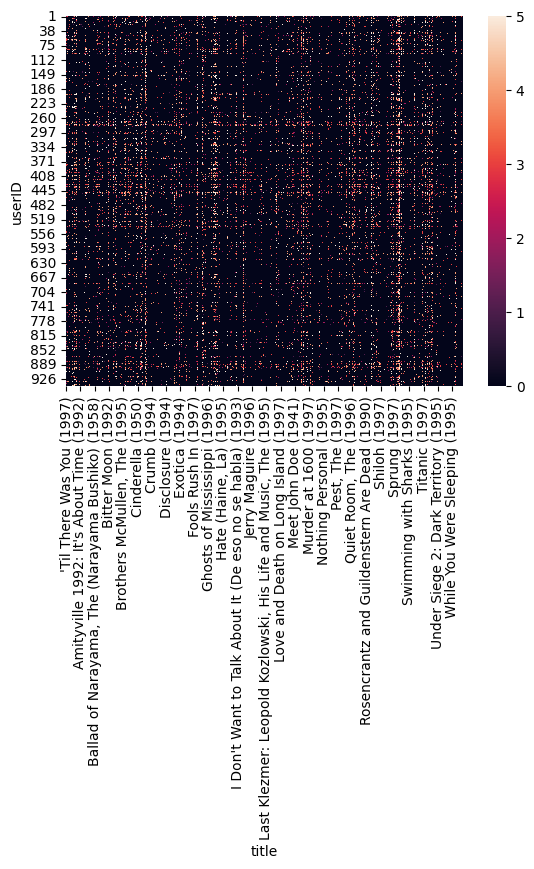

In [87]:
sns.heatmap(data)

In [88]:
from sklearn.neighbors import NearestNeighbors

# 3. Le model

In [89]:
model = NearestNeighbors(n_neighbors=5, radius=1)
model.fit(data)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [98]:
distance, index = model.kneighbors(X=data,
                 n_neighbors=5
                )
distance, index 

(array([[ 0.        , 54.83611948, 55.22906843, 55.3895297 , 56.85068161],
        [ 0.        , 25.63201124, 27.73084925, 27.78488798, 27.82085549],
        [ 0.        , 20.5669638 , 20.97617696, 21.04756518, 21.04756518],
        ...,
        [ 0.        , 20.71231518, 20.76053949, 20.88061302, 20.92844954],
        [ 0.        , 36.82390528, 37.18870796, 37.28270376, 37.73592453],
        [ 0.        , 43.35896678, 43.8634244 , 44.05678154, 44.82186966]],
       shape=(943, 5)),
 array([[  0, 737, 520, 932, 714],
        [  1, 700, 265, 130, 128],
        [  2, 316, 655, 919, 334],
        ...,
        [940, 741, 440, 816, 796],
        [941, 162, 855,  60, 728],
        [942, 932, 773, 745,  36]], shape=(943, 5)))

In [125]:
data.loc[2][data.loc[2]==5]

title
As Good As It Gets (1997)        5.0
Emma (1996)                      5.0
Fargo (1996)                     5.0
Godfather, The (1972)            5.0
Good Will Hunting (1997)         5.0
Kolya (1996)                     5.0
L.A. Confidential (1997)         5.0
Secrets & Lies (1996)            5.0
Sense and Sensibility (1995)     5.0
Shall We Dance? (1996)           5.0
Star Wars (1977)                 5.0
Titanic (1997)                   5.0
Wings of the Dove, The (1997)    5.0
Name: 2, dtype: float64

In [179]:
def get_film(df, index, rating):
    """return film with rating egal to 5"""
    return df.loc[index][df.loc[index]>=rating].index.to_list()


In [172]:
d = get_film(data, 4) + get_film(data, 42)
a = pd.array(d)
a.value_counts().sort_values(ascending=False)

Star Wars (1977)                               2
Assignment, The (1997)                         1
Blues Brothers 2000 (1998)                     1
Contact (1997)                                 1
Air Force One (1997)                           1
                                              ..
Toy Story (1995)                               1
True Lies (1994)                               1
When Harry Met Sally... (1989)                 1
Winnie the Pooh and the Blustery Day (1968)    1
Wizard of Oz, The (1939)                       1
Name: count, Length: 61, dtype: Int64

In [184]:
def movie_recommander(model, df, userID, n_neighbors=5, rating=5, n_max_film=10):
    _, list_index = model.kneighbors(X=df,n_neighbors=n_neighbors)
    list_film = []
    for index in list_index[userID][1:]:
        list_film += get_film(df, index, rating)
    df_list_film = pd.array(list_film)
    return df_list_film.value_counts().sort_values(ascending=False).head(n_max_film)

In [186]:
movie_recommander(model, data, 42)

2001: A Space Odyssey (1968)      3
Braveheart (1995)                 3
Pulp Fiction (1994)               3
Fargo (1996)                      3
Blade Runner (1982)               2
Apocalypse Now (1979)             2
Godfather, The (1972)             2
Full Metal Jacket (1987)          2
Shine (1996)                      2
Raiders of the Lost Ark (1981)    2
Name: count, dtype: Int64